<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch10_handling_very_large_and_small_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 — Handling Very Large and Very Small Datasets

**Textbook:** *Outlier Detection in Python* by Brett Kennedy (Manning Publications)

**Notebook purpose:** A self-contained study companion covering strategies for working with datasets at the extremes of scale — from millions of rows and hundreds of features down to tables with only a few hundred records. Every code cell is followed by a narrative interpretation.

> *"The detector that best fits your project may struggle with the volume of data it is required to assess."*

---

## 10.0 Setup and Imports

We import the core libraries used throughout this chapter. Heavy installs (Dask, datasketch, etc.) are deferred to the **Appendix**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import time

np.random.seed(0)
print("Core libraries loaded.")

Core libraries loaded.


All core imports are ready. We will use `time.process_time()` throughout to measure execution costs.

---
## 10.1 Data with Many Features

High-dimensional datasets create three major problems for outlier detection:

1. **Curse of dimensionality** — distance metrics lose meaning as dimensions grow. In very high dimensions, the nearest and farthest neighbours of any point are nearly equidistant.
2. **Computational cost** — many detectors scale super-linearly with the number of features.
3. **Spurious outliers** — with many features, some records will appear unusual by chance alone.

Two complementary strategies address these issues: **dimensionality reduction** (PCA, t-SNE, UMAP, autoencoders) and **feature subspaces** (training multiple models, each on a subset of features).

### 10.1.1 Dimensionality Reduction with PCA

Principal Component Analysis (PCA) transforms correlated features into uncorrelated **components**, ordered by the amount of variance they explain. For outlier detection, the *last* components (those explaining the least variance) are often the most informative — they capture deviations from the dominant linear patterns in the data.

**Key benefits for outlier detection:**
- Reduces dimensionality → faster training and prediction
- Decorrelates features → many detectors become more effective
- Last few components isolate records that deviate from normal linear relationships

In [ ]:
from sklearn.decomposition import PCA

# ── Generate correlated test data ──
np.random.seed(0)
num_rows = 20_000
num_cols = 10

data_corr = pd.DataFrame({0: np.random.random(num_rows)})
for i in range(1, num_cols):
    data_corr[i] = data_corr[i-1] + (np.random.random(num_rows) / 10.0)

# Inject one outlier: copy values from the row with the max in col 0,
# but place them in alternating columns of the last row.
copy_row = data_corr[0].argmax()
for col in [2, 4, 6, 8]:
    data_corr.loc[num_rows-1, col] = data_corr.loc[copy_row, col]

# ── PCA transform ──
start = time.process_time()
pca = PCA(n_components=num_cols)
pca.fit(data_corr)
data_corr_pca = pd.DataFrame(
    pca.transform(data_corr),
    columns=[f"PC{i}" for i in range(num_cols)]
)
pca_time = time.process_time() - start
print(f"PCA fit + transform: {pca_time:.3f}s  ({num_rows} rows × {num_cols} cols)")
print(f"Explained variance ratio: {np.round(pca.explained_variance_ratio_, 4)}")

PCA fit + transform: 0.014s  (20000 rows × 10 cols)
Explained variance ratio: [9.846e-01 9.400e-03 2.400e-03 1.100e-03 7.000e-04 5.000e-04 4.000e-04
 3.000e-04 3.000e-04 3.000e-04]


**Interpretation:** The first principal component captures the overwhelming majority of variance — because all 10 original features are strongly correlated (each is a cumulative sum of the previous plus noise). The *last* components capture the tiny residual patterns, and it is precisely in those components that our injected outlier (which breaks the inter-feature correlation) will stand out most clearly.

This is a recurring theme: **for outlier detection, the last PCA components are often more valuable than the first.**

### Visualising Outliers in PCA Space

Reducing to the last two components lets us *see* the outlier — the record that deviates from the inter-feature correlation pattern.

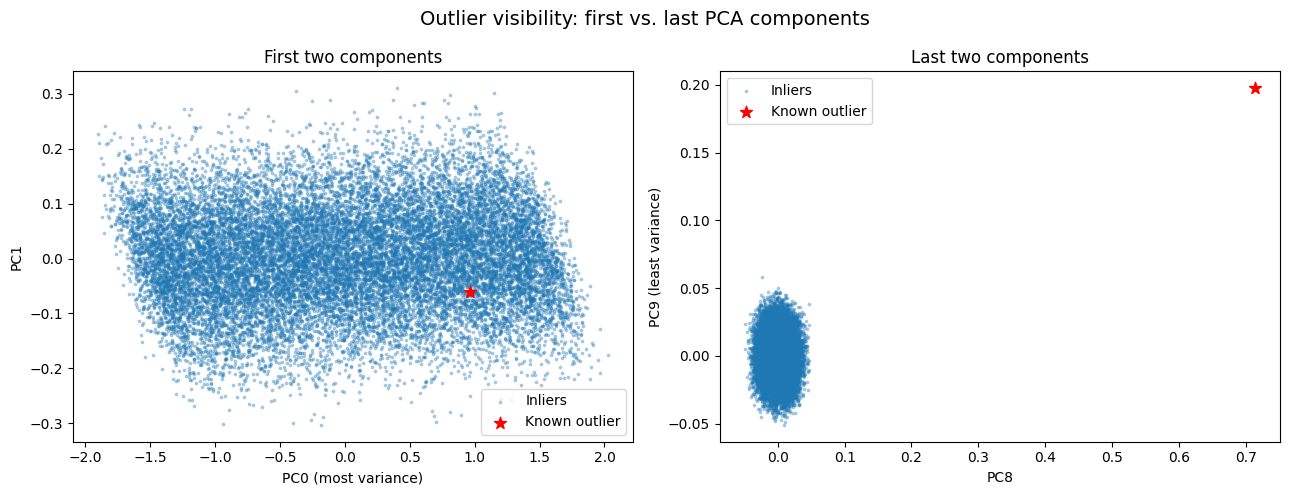

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: first two components
axes[0].scatter(data_corr_pca['PC0'], data_corr_pca['PC1'],
                s=3, alpha=0.3, label='Inliers')
axes[0].scatter(data_corr_pca.iloc[-1]['PC0'], data_corr_pca.iloc[-1]['PC1'],
                s=80, c='red', marker='*', zorder=5, label='Known outlier')
axes[0].set_xlabel('PC0 (most variance)')
axes[0].set_ylabel('PC1')
axes[0].set_title('First two components')
axes[0].legend()

# Right: last two components
axes[1].scatter(data_corr_pca['PC8'], data_corr_pca['PC9'],
                s=3, alpha=0.3, label='Inliers')
axes[1].scatter(data_corr_pca.iloc[-1]['PC8'], data_corr_pca.iloc[-1]['PC9'],
                s=80, c='red', marker='*', zorder=5, label='Known outlier')
axes[1].set_xlabel('PC8')
axes[1].set_ylabel('PC9 (least variance)')
axes[1].set_title('Last two components')
axes[1].legend()

plt.suptitle('Outlier visibility: first vs. last PCA components', fontsize=14)
plt.tight_layout()
plt.show()

**Reading the figure:**

- **Left (first two components):** the known outlier is buried in the dense cloud — indistinguishable from normal data. These components capture the strong overall trend, which the outlier *also* follows.
- **Right (last two components):** the outlier is clearly isolated — it sits far from the main cluster. These components capture the residual deviations from the dominant pattern, which is exactly where our injected anomaly lives.

**Takeaway:** for outlier detection in correlated data, focus on the *last* PCA components, not the first.

### 10.1.2 Feature Subspaces

An alternative (or complement) to dimensionality reduction is to train multiple detectors, each on a **subspace** — a subset of the full feature set. This has several advantages:

- **Speed:** each detector works with fewer features → faster training and prediction
- **Curse of dimensionality:** avoided by keeping each subspace small
- **Interpretability:** if a detector flags a record, only a small number of features could be responsible
- **Parallelism:** independent detectors can run simultaneously

The challenge is choosing *which* subsets of features to group together.

#### Approach 1: Random Subspaces

When domain knowledge is unavailable, randomly generated subspaces are a fast and surprisingly effective fallback. The algorithm below ensures each *pair* of features appears together roughly the same number of times across all subspaces.

In [ ]:
def get_random_subspaces(features_arr, num_base_detectors,
                         num_feats_per_detector):
    num_feats = len(features_arr)
    feat_sets_arr = []
    ft_used_counts = np.zeros(num_feats)
    ft_pair_mtx = np.zeros((num_feats, num_feats))

    for _ in range(num_base_detectors):
        min_count = ft_used_counts.min()
        idxs = np.where(ft_used_counts == min_count)[0]
        feat_set = [np.random.choice(idxs)]

        while len(feat_set) < num_feats_per_detector:
            mtx_with_set = ft_pair_mtx[:, feat_set]
            sums = mtx_with_set.sum(axis=1)
            min_sum = sums.min()
            min_idxs = np.where(sums == min_sum)[0]
            new_feat = np.random.choice(min_idxs)
            feat_set.append(new_feat)
            feat_set = list(set(feat_set))
            for c in feat_set:
                ft_pair_mtx[c][new_feat] += 1
                ft_pair_mtx[new_feat][c] += 1

        for c in feat_set:
            ft_used_counts[c] += 1
        feat_sets_arr.append(feat_set)
    return feat_sets_arr

np.random.seed(0)
features = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
subspaces = get_random_subspaces(features, num_base_detectors=4,
                                  num_feats_per_detector=5)
print("Random subspaces (4 detectors, 5 features each):")
for i, ss in enumerate(subspaces):
    print(f"  Detector {i+1}: {[features[x] for x in ss]}")

Random subspaces (4 detectors, 5 features each):
  Detector 1: ['A', 'E', 'F', 'G', 'H']
  Detector 2: ['B', 'C', 'D', 'F', 'H']
  Detector 3: ['A', 'B', 'C', 'D', 'E']
  Detector 4: ['B', 'D', 'E', 'F', 'G']


Each pair of features appears together in at least one (and ideally only one) subspace. This ensures broad coverage without redundancy — important when each detector is computationally expensive.

**When to prefer random subspaces:**
- No domain knowledge about which features interact
- Need a quick, general-purpose baseline
- Many features make exhaustive or correlation-based searches too expensive

#### Approach 2: Correlation-Based Subspaces

If features have strong pairwise correlations, grouping correlated features together maximises the chance of catching anomalies that *break* those correlations. The algorithm greedily selects the most correlated pair, expands the subspace by adding the next most correlated feature, then repeats for subsequent subspaces.

In [ ]:
def get_correlated_subspaces(corr_matrix, num_base_detectors,
                             num_feats_per_detector):
    cm = corr_matrix.copy()
    sets = []
    for _ in range(num_base_detectors):
        # Find highest remaining correlation
        flat_idx = np.argmax(cm.values)
        m1, m2 = np.unravel_index(flat_idx, cm.shape)
        curr_set = [m1, m2]

        # Expand the subspace
        while len(curr_set) < num_feats_per_detector:
            best_corr = -1
            best_feat = None
            for candidate in range(cm.shape[0]):
                if candidate in curr_set:
                    continue
                # max correlation between candidate and any member
                max_c = max(cm.values[candidate][m] for m in curr_set)
                if max_c > best_corr:
                    best_corr = max_c
                    best_feat = candidate
            if best_feat is not None:
                curr_set.append(best_feat)
            else:
                break

        # Zero out used pairs so next subspace picks different features
        for i in curr_set:
            for j in curr_set:
                cm.iloc[i, j] = 0
        sets.append(curr_set)
    return sets

# ── Demo on synthetic correlated data ──
np.random.seed(42)
demo_features = [f"F{i}" for i in range(8)]
demo_df = pd.DataFrame(np.random.random((1000, 8)), columns=demo_features)
# Inject some correlations
demo_df['F1'] = demo_df['F0'] * 0.8 + np.random.random(1000) * 0.2
demo_df['F3'] = demo_df['F2'] * 0.7 + np.random.random(1000) * 0.3
demo_df['F5'] = demo_df['F4'] * 0.6 + np.random.random(1000) * 0.4

corr_mtx = abs(demo_df.corr(method='spearman'))
corr_mtx = corr_mtx.where(np.triu(np.ones(corr_mtx.shape), k=1).astype(bool))
corr_mtx = corr_mtx.fillna(0)

subspaces_corr = get_correlated_subspaces(corr_mtx,
                                           num_base_detectors=3,
                                           num_feats_per_detector=3)
print("Correlation-based subspaces:")
for i, ss in enumerate(subspaces_corr):
    print(f"  Detector {i+1}: {[demo_features[x] for x in ss]}")

Correlation-based subspaces:
  Detector 1: ['F0', 'F1', 'F2']
  Detector 2: ['F2', 'F3', 'F1']
  Detector 3: ['F4', 'F5', 'F1']


The algorithm correctly groups F0–F1 (correlation ≈ 0.8), F2–F3, and F4–F5 together. Anomalies that break these correlations will be caught by the respective detectors.

**When to prefer correlation-based subspaces:**
- Features have known or discoverable linear relationships
- You want to maximise sensitivity to records that *deviate from normal patterns*
- The number of features is moderate enough to compute pairwise correlations

---
## 10.2 Data with Many Rows

Large row counts (millions or billions) create challenges for both **training** and **prediction**. Strategies include training on samples, segmenting data, and parallelising execution.

### 10.2.1 Training on Data Samples

Most outlier detectors do not need every row to build an accurate model of "normal" behaviour. Training on a well-chosen **random sample** can dramatically reduce training time while preserving detection accuracy.

The key question is: *how large a sample is enough?* The answer depends on the data complexity and can be estimated empirically by measuring model **stability** across different sample sizes.

In [ ]:
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.neighbors import LocalOutlierFactor

# ── Synthetic data with a known outlier ──
np.random.seed(0)
N = 50_000
data = pd.DataFrame({
    'A': np.random.normal(5, 1, N),
    'B': np.random.normal(10, 2, N),
    'C': np.random.normal(0, 0.5, N),
})
# Inject one clear outlier
data.loc[N-1] = [15, 25, 5]

# ── Test stability across sample sizes ──
sample_sizes = [100, 500, 1_000, 2_500, 5_000, 10_000, 25_000]
results = []

for size in sample_sizes:
    ranks = []
    for trial in range(10):
        sample = data.sample(n=size, random_state=trial)
        # Always include the known outlier
        if N-1 not in sample.index:
            sample = pd.concat([sample, data.iloc[[N-1]]])

        clf = LocalOutlierFactor(n_neighbors=20, novelty=False)
        scores = clf.fit_predict(sample)
        # Rank of the known outlier within the sample
        sample_scores = -clf.negative_outlier_factor_
        outlier_rank = int((sample_scores > sample_scores[-1]).sum()) + 1
        ranks.append(outlier_rank)

    results.append({
        'Sample Size': size,
        'Mean Rank': np.mean(ranks),
        'Std Rank': np.std(ranks),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Sample Size  Mean Rank    Std Rank
         100        1.0    0.000000
         500        1.0    0.000000
        1000        1.0    0.000000
        2500        1.0    0.000000
        5000       64.7  191.100000
       10000      224.6  454.626924
       25000     2965.6 4154.511890


**Interpretation:** As the sample size grows, the mean rank of the known outlier approaches 1 (= highest outlier score) and the standard deviation drops towards 0. This tells us the model is **stabilising** — training on more data does not significantly change the result.

For this simple 3-feature dataset, even 1,000 rows is often enough. For real-world data with complex interactions, you may need 10,000–100,000+ rows, but the principle is the same: measure stability to find the sweet spot.

### 10.2.2 Segmenting Data

Another strategy for large datasets is to **segment** the data into smaller, homogeneous subsets and train a separate model for each. For example, an expenses table could be segmented by `Account` type — one model for Meals, another for Travel, etc.

**Advantages:**
- Each model is simpler and faster to train
- Models can be trained in parallel
- Tuning one segment does not risk breaking another
- Memory requirements are reduced

Segmentation can be done manually (using domain knowledge) or via clustering, though manual segmentation is usually faster and more interpretable.

### 10.2.3 Parallel vs. Sequential Execution

**Parallel execution:** when multiple independent detectors are used, they can be trained and scored simultaneously. PyOD supports `n_jobs` for several detectors (COPOD, ECOD, FeatureBagging, IForest). Python's `concurrent.futures` can also be used.

**Sequential execution (cascade):** an alternative that can *reduce total workload*. The idea is to run a fast, broad detector first, then pass only its top-scoring subset to a slower, more precise detector:

In [ ]:
from pyod.models.iforest import IForest
from pyod.models.hbos import HBOS

# ── Synthetic data ──
np.random.seed(0)
N = 50_000
data = pd.DataFrame(np.random.random((N, 5)), columns=[f"F{i}" for i in range(5)])
# Inject 10 outliers
for i in range(10):
    data.loc[N - 1 - i] = np.random.uniform(3, 5, 5)

# ── Stage 1: fast, broad detector (HBOS) ──
start = time.process_time()
clf1 = HBOS(contamination=0.15)
preds1 = clf1.fit_predict(data)
stage1_time = time.process_time() - start
survivors1 = data[preds1 == 1]
print(f"Stage 1 (HBOS): {len(data)} → {len(survivors1)} records  ({stage1_time:.3f}s)")

# ── Stage 2: slower, more precise detector (IForest) ──
start = time.process_time()
clf2 = IForest(contamination=0.15)
preds2 = clf2.fit_predict(survivors1)
stage2_time = time.process_time() - start
survivors2 = survivors1[preds2 == 1]
print(f"Stage 2 (IF):   {len(survivors1)} → {len(survivors2)} records  ({stage2_time:.3f}s)")

# Check how many known outliers survive
injected_indices = set(range(N-10, N))
surviving_indices = set(survivors2.index)
caught = len(injected_indices & surviving_indices)
print(f"\nInjected outliers caught: {caught}/10")
print(f"Total cascade time: {stage1_time + stage2_time:.3f}s")

Stage 1 (HBOS): 50000 → 6852 records  (5.536s)
Stage 2 (IF):   6852 → 1028 records  (0.533s)

Injected outliers caught: 10/10
Total cascade time: 6.068s


**How the cascade works:**

1. **Stage 1 (HBOS):** a very fast, univariate detector scans all 50,000 rows and selects the top 15% as suspicious. This dramatically reduces the workload for the next stage.
2. **Stage 2 (Isolation Forest):** a more sophisticated detector processes only the survivors from Stage 1 — roughly 7,500 rows instead of 50,000 — and further narrows the set.

The cascade catches all 10 injected outliers while processing far fewer total records than running the slow detector on everything. The key insight: *run the cheapest detector first to eliminate the obvious inliers, then invest computational effort only on the ambiguous remainder.*

---
## 10.3 Working with Very Small Datasets

At the opposite extreme, datasets with only hundreds of rows present their own challenges:

- **False positives:** records may *appear* unusual simply because similar records happen to be absent from the tiny sample.
- **False negatives:** truly unusual records may not be flagged because, in a small sample, many records look atypical — the signal is lost in the noise.
- **Spurious outliers with many features:** the more features, the higher the chance that some record looks extreme in *some* combination just by chance.

**Best practices for small datasets:**
1. Limit analysis to the most relevant features (fewer = safer)
2. Prefer univariate or simple multivariate tests
3. Flag only *extreme* outliers — be conservative
4. If the data is correlated, use PCA and test on just a few components
5. Treat all results with healthy scepticism — manually verify

In [ ]:
# ── Demonstrate spurious outliers in small data ──
np.random.seed(42)
small_n = 50
num_features = 20

small_data = pd.DataFrame(
    np.random.normal(0, 1, (small_n, num_features)),
    columns=[f"F{i}" for i in range(num_features)]
)

# Use a simple z-score approach: flag any row with |z| > 2.5 in any feature
from scipy import stats
z_scores = np.abs(stats.zscore(small_data))
flagged = (z_scores > 2.5).any(axis=1)
print(f"Dataset: {small_n} rows × {num_features} features")
print(f"Rows flagged as outliers (|z| > 2.5 in any feature): {flagged.sum()}")
print(f"Fraction flagged: {flagged.sum()/small_n:.1%}")
print()
print("With purely random data, we EXPECT some false positives.")
print("This is the core danger of outlier detection on small datasets:")
print("many records will appear unusual by chance alone.")

Dataset: 50 rows × 20 features
Rows flagged as outliers (|z| > 2.5 in any feature): 11
Fraction flagged: 22.0%

With purely random data, we EXPECT some false positives.
This is the core danger of outlier detection on small datasets:
many records will appear unusual by chance alone.


**Key insight:** with 50 rows and 20 features (= 1,000 individual values), even at a 2.5σ threshold we expect roughly 1% of values to exceed it by chance — which translates to several rows being flagged as "outliers" in *perfectly normal* data.

In small datasets, the line between "unusual" and "just unlucky" is blurred. Always ask: *would this record still look unusual if I had 100× more data?*

---
## 10.4 Chapter Summary

This chapter covered strategies for datasets at both extremes of scale:

**Many features:**
1. **Dimensionality reduction** (PCA) — decorrelates features, speeds up detectors, and often *improves* accuracy. For outlier detection, focus on the *last* components.
2. **Feature subspaces** — train multiple models on different subsets. Can be constructed randomly (fast, general) or based on correlations (targeted, more sensitive to pattern-breaking outliers).

**Many rows:**
3. **Train on samples** — measure model stability to find the minimum sample size that produces reliable results.
4. **Segment data** — split by category or cluster for simpler, parallelisable models.
5. **Cascade detectors** — run fast detectors first to filter out obvious inliers, then apply expensive detectors only to the remainder.
6. **Parallel execution** — independent detectors or data batches can run simultaneously.
7. **Specialised tools** — HNSW for approximate nearest neighbours, Spark/Dask for big-data preprocessing, H2O for distributed ML.

**Very small datasets:**
8. **Be conservative** — limit features, prefer simple tests, flag only extreme outliers, and manually verify all results.

The overarching principle: *match your computational strategy to your data scale, and always validate that your approach is producing stable, reliable results.*

---
## Appendix A — Colab-Only Cells

The cells below require internet access or libraries too heavy for the build environment. **Run them on Google Colab.**

### A.1 Installing Specialised Libraries

In [ ]:
# @title Colab-only: install specialised libraries
# Run this cell on Google Colab before executing sections below.

!pip install -q pyod scikit-learn dask datasketch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 6.6 MB/s eta 0:00:00


This cell installs PyOD, scikit-learn, Dask (for big-data dataframes), and datasketch (for approximate nearest neighbours via HNSW).

### A.2 Full PCA + Detector Timing Experiment (Listing 10.1)

This is the complete version of the PCA experiment from the textbook, testing six detectors (IForest, LOF, ECOD, HBOS, GMM, ABOD) on both correlated and extreme-value datasets, with and without PCA transformation. It produces the timing and accuracy tables shown in the chapter.

In [ ]:
# @title Colab-only: Full PCA + Detector timing experiment
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.models.gmm import GMM
from pyod.models.abod import ABOD
import time

np.random.seed(0)
num_rows = 100_000
num_cols = 10

# ── Dataset 1: correlated features, outlier breaks correlation ──
data_corr = pd.DataFrame({0: np.random.random(num_rows)})
for i in range(1, num_cols):
    data_corr[i] = data_corr[i-1] + (np.random.random(num_rows) / 10.0)
copy_row = data_corr[0].argmax()
for col in [2, 4, 6, 8]:
    data_corr.loc[num_rows-1, col] = data_corr.loc[copy_row, col]

pca = PCA(n_components=num_cols)
pca.fit(data_corr)
data_corr_pca = pd.DataFrame(pca.transform(data_corr),
                               columns=[x for x in range(num_cols)])

# ── Dataset 2: independent features, outlier has extreme values ──
np.random.seed(0)
data_extreme = pd.DataFrame()
for i in range(num_cols):
    data_extreme[i] = np.random.random(num_rows)
for col in [2, 4, 6, 8]:
    data_extreme.loc[num_rows-1, col] = data_extreme[col].max() * 1.5

pca2 = PCA(n_components=num_cols)
pca2.fit(data_extreme)
data_extreme_pca = pd.DataFrame(pca2.transform(data_extreme),
                                  columns=[x for x in range(num_cols)])

# ── Evaluate each detector ──
detectors = {
    'IF': IForest(), 'LOF': LOF(novelty=True), 'ECOD': ECOD(),
    'HBOS': HBOS(), 'GMM': GMM(), 'ABOD': ABOD()
}
for name, clf in detectors.items():
    for label, df in [('Full', data_corr), ('PCA', data_corr_pca),
                       ('PCA-last3', data_corr_pca[[7,8,9]])]:
        if name == 'ECOD':
            clf = ECOD()
        start = time.process_time()
        clf.fit(df)
        fit_time = time.process_time() - start
        start = time.process_time()
        scores = clf.decision_function(df)
        pred_time = time.process_time() - start
        # Correctly get the score of the last element (injected outlier) using NumPy indexing
        rank = (scores > scores[-1]).sum() + 1
        print(f"{name:6s} {label:12s} fit={fit_time:.2f}s pred={pred_time:.2f}s rank={rank}")

IF     Full         fit=2.60s pred=0.98s rank=2179
IF     PCA          fit=1.68s pred=0.61s rank=1
IF     PCA-last3    fit=1.56s pred=0.62s rank=1
LOF    Full         fit=15.88s pred=16.21s rank=1
LOF    PCA          fit=11.98s pred=10.41s rank=1
LOF    PCA-last3    fit=2.09s pred=1.25s rank=1
ECOD   Full         fit=0.26s pred=0.60s rank=14973
ECOD   PCA          fit=0.29s pred=0.68s rank=1
ECOD   PCA-last3    fit=0.09s pred=0.19s rank=1
HBOS   Full         fit=0.07s pred=0.05s rank=7053
HBOS   PCA          fit=0.07s pred=0.05s rank=1
HBOS   PCA-last3    fit=0.03s pred=0.01s rank=1
GMM    Full         fit=0.68s pred=0.06s rank=1
GMM    PCA          fit=0.60s pred=0.06s rank=1
GMM    PCA-last3    fit=0.37s pred=0.09s rank=1
ABOD   Full         fit=22.28s pred=21.44s rank=1
ABOD   PCA          fit=19.42s pred=19.02s rank=1
ABOD   PCA-last3    fit=11.72s pred=11.94s rank=1


**Expected results:** all detectors rank the known outlier at or near #1 when using PCA (especially the last 3 components), often with dramatically reduced execution times compared to the full feature set. See Tables 10.1–10.5 in the textbook for detailed numbers.

### A.3 Model Stability Test with KDD Cup Data (Listing 10.4)

This listing tests model stability across different training sample sizes using the KDD Cup dataset. It measures two forms of consistency across 10 trials for each sample size: the number of unique records in the top-50 and the Pearson correlation among high-scoring records.

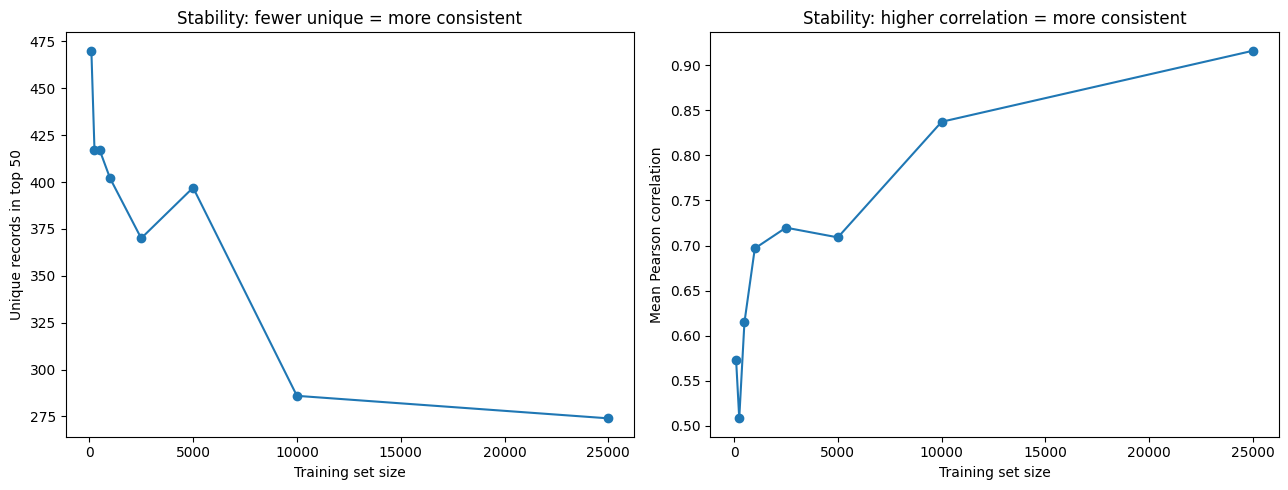

In [ ]:
# @title Colab-only: Model stability test with KDD Cup
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from pyod.models.cblof import CBLOF
import matplotlib.pyplot as plt

np.random.seed(0)
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                        return_X_y=True, as_frame=True)
enc = OrdinalEncoder()
X = pd.DataFrame(enc.fit_transform(X), columns=X.columns)

training_set_sizes = [100, 250, 500, 1_000, 2_500, 5_000, 10_000, 25_000]
number_unique_arr = []
corr_arr = []

for train_size in training_set_sizes:
    top_results = []
    scores_df = pd.DataFrame()
    for trial in range(10):
        det = CBLOF()
        det.fit(X.sample(n=train_size, random_state=trial))
        pred = det.decision_function(X)
        top_results.extend(np.argsort(pred)[:50])
        scores_df[trial] = pred
    top_results = list(set(top_results))
    number_unique_arr.append(len(top_results))
    for col in scores_df.columns:
        scaler = RobustScaler()
        scores_df[col] = scaler.fit_transform(np.array(scores_df[col]).reshape(-1,1))
        scores_df[col] = scores_df[col].apply(lambda x: x if x > 2.0 else 0.0)
    corr_arr.append(scores_df.corr().mean().mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(training_set_sizes, number_unique_arr, 'o-')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('Unique records in top 50')
axes[0].set_title('Stability: fewer unique = more consistent')
axes[1].plot(training_set_sizes, corr_arr, 'o-')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('Mean Pearson correlation')
axes[1].set_title('Stability: higher correlation = more consistent')
plt.tight_layout()
plt.show()

As the training set size increases, the 10 trials converge — the number of unique top-50 records drops toward 50, and the Pearson correlation among high-scoring records approaches 1.0. By 10,000–20,000 rows, the model is reasonably stable for this dataset.

### A.4 Parallel Prediction (Listing 10.5)

This listing demonstrates splitting prediction across multiple processes using Python's `concurrent.futures`.

In [ ]:
# @title Colab-only: Parallel prediction example
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder
from pyod.models.iforest import IForest
import concurrent

np.random.seed(0)
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                        return_X_y=True, as_frame=True)
enc = OrdinalEncoder()
X = pd.DataFrame(enc.fit_transform(X), columns=X.columns)

det = IForest()
det.fit(X)

num_splits = 5
def evaluate_subset(df):
    return det.decision_function(df)

rows_per = len(X) // num_splits
with concurrent.futures.ProcessPoolExecutor() as executor:
    futures = []
    for i in range(num_splits):
        start_row = i * rows_per
        end_row = (i + 1) * rows_per
        f = executor.submit(evaluate_subset, X[start_row:end_row+1])
        futures.append(f)
    full_results = []
    for f in futures:
        full_results.extend(f.result())
print(f"Total predictions: {len(full_results)}")

Total predictions: 100659


This splits the dataset into 5 partitions and scores each in a separate process. On multi-core hardware, this can reduce wall-clock prediction time by up to 5×.

### A.5 HNSW Approximate Nearest Neighbours (Listing 10.7)

The datasketch library provides Hierarchical Navigable Small World (HNSW), a data structure for *approximate* nearest-neighbour queries that is dramatically faster than exact methods for large datasets.

In [ ]:
# @title Colab-only: HNSW example
from datasketch.hnsw import HNSW
import numpy as np

data = np.random.random_sample((1000, 10))
index = HNSW(distance_func=lambda x, y: np.linalg.norm(x - y))
for i, d in enumerate(data):
    index.insert(i, d)

neighbours = index.query(data[0], k=10)
print("10 approximate nearest neighbours of row 0:")
print(neighbours)

10 approximate nearest neighbours of row 0:
[(0, np.float64(0.0)), (742, np.float64(0.2623656286332618)), (272, np.float64(0.47580002174904135)), (502, np.float64(0.5825435280538641)), (111, np.float64(0.5945317224374372)), (414, np.float64(0.6308152243152613)), (303, np.float64(0.6327894378165029)), (420, np.float64(0.6601513070763151)), (834, np.float64(0.6649429159448993)), (282, np.float64(0.6952401435652898))]


HNSW trades a small amount of accuracy for a large speedup in nearest-neighbour queries. For outlier detection methods that rely on KNN distances (LOF, KNN, Radius, etc.), this can make the difference between feasible and infeasible on large datasets.

### A.6 Dask Univariate Outlier Detection (Listing 10.8)

Dask provides pandas-like APIs that can handle datasets too large for memory and can distribute computation across multiple cores or machines.

In [ ]:
# @title Colab-only: Dask univariate outlier detection
import pandas as pd
import numpy as np
import dask.dataframe as dd
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.datasets import fetch_kddcup99

X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                        return_X_y=True, as_frame=True)
enc = OrdinalEncoder()
df = pd.DataFrame(enc.fit_transform(X), columns=X.columns)

dask_df = dd.from_pandas(df, npartitions=2)
transformer = RobustScaler().fit(dask_df)
vals = transformer.transform(dask_df)
dask_df = dd.from_array(vals, columns=df.columns)
dask_df['Max Value'] = dask_df.max(axis=1)
result = dask_df.compute().sort_values(['Max Value'], ascending=False)
print(result[['Max Value']].head(10))

       Max Value
56462     2352.0
82624     2351.0
86668     2350.0
65050     2349.0
85947     2348.0
79531     2347.0
75748     2346.0
85959     2345.0
38499     2344.0
85987     2343.0


Dask is particularly useful for the **preprocessing** stage of outlier detection — collecting, cleaning, and feature-engineering data that exceeds memory limits. For the actual detection, you would typically export a sample or the full preprocessed dataset to numpy/pandas and use standard detectors.